In [1]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

np.random.seed(42)

X = np.array([0.05, 0.10])
y = np.array([0.01, 0.99])

w1, w2, w3, w4 = 0.15, 0.20, 0.25, 0.30
w5, w6, w7, w8 = 0.40, 0.45, 0.50, 0.55
b1, b2 = 0.35, 0.60
lr = 0.5

In [2]:
i1 = X[0]*w1 + X[1]*w2 + b1
i2 = X[0]*w3 + X[1]*w4 + b1
a1 = sigmoid(i1)
a2 = sigmoid(i2)

print("=== Hidden Layer ===")
print(f"i1 (net input to h1) = {i1:.6f}")
print(f"i2 (net input to h2) = {i2:.6f}")
print(f"a1 (activation h1)   = {a1:.6f}")
print(f"a2 (activation h2)   = {a2:.6f}")

=== Hidden Layer ===
i1 (net input to h1) = 0.377500
i2 (net input to h2) = 0.392500
a1 (activation h1)   = 0.593270
a2 (activation h2)   = 0.596884


In [3]:
i3 = a1*w5 + a2*w6 + b2
i4 = a1*w7 + a2*w8 + b2
y1 = sigmoid(i3)
y2 = sigmoid(i4)

print("=== Output Layer ===")
print(f"i3 (net input to o1) = {i3:.6f}")
print(f"i4 (net input to o2) = {i4:.6f}")
print(f"y1 (output 1)        = {y1:.6f}")
print(f"y2 (output 2)        = {y2:.6f}")

=== Output Layer ===
i3 (net input to o1) = 1.105906
i4 (net input to o2) = 1.224921
y1 (output 1)        = 0.751365
y2 (output 2)        = 0.772928


In [4]:
loss = 0.5 * ((y[0] - y1)**2 + (y[1] - y2)**2)
print(f"=== Loss (Squared Error) ===")
print(f"Loss = {loss:.6f}")

=== Loss (Squared Error) ===
Loss = 0.298371


In [5]:
err1 = (y[0] - y1) * sigmoid_derivative(y1)
err2 = (y[1] - y2) * sigmoid_derivative(y2)

print("=== Output Layer Errors ===")
print(f"err1 = {err1:.6f}")
print(f"err2 = {err2:.6f}")
print()
print("err1 is negative because y1 > target (0.01) → network overshot")
print("err2 is positive because y2 < target (0.99) → network undershot")

=== Output Layer Errors ===
err1 = -0.138499
err2 = 0.038098

err1 is negative because y1 > target (0.01) → network overshot
err2 is positive because y2 < target (0.99) → network undershot


In [6]:
grad_w5 = err1 * a1
grad_w6 = err1 * a2
grad_w7 = err2 * a1
grad_w8 = err2 * a2

print("=== Gradients for Output Weights ===")
print(f"grad_w5 = {grad_w5:.6f}")
print(f"grad_w6 = {grad_w6:.6f}")
print(f"grad_w7 = {grad_w7:.6f}")
print(f"grad_w8 = {grad_w8:.6f}")

=== Gradients for Output Weights ===
grad_w5 = -0.082167
grad_w6 = -0.082668
grad_w7 = 0.022603
grad_w8 = 0.022740


In [7]:
err_h1 = (err1*w5 + err2*w7) * sigmoid_derivative(a1)
err_h2 = (err1*w6 + err2*w8) * sigmoid_derivative(a2)

print("=== Hidden Layer Errors ===")
print(f"err_h1 = {err_h1:.6f}")
print(f"err_h2 = {err_h2:.6f}")
print()
print("We sum over next layer errors because each hidden neuron contributes")
print("to ALL output neurons, so total responsibility = sum of all downstream errors.")

=== Hidden Layer Errors ===
err_h1 = -0.008771
err_h2 = -0.009954

We sum over next layer errors because each hidden neuron contributes
to ALL output neurons, so total responsibility = sum of all downstream errors.


In [8]:
w5 += lr * grad_w5
w6 += lr * grad_w6
w7 += lr * grad_w7
w8 += lr * grad_w8

w1 += lr * err_h1 * X[0]
w2 += lr * err_h1 * X[1]
w3 += lr * err_h2 * X[0]
w4 += lr * err_h2 * X[1]

b2 += lr * (err1 + err2)
b1 += lr * (err_h1 + err_h2)

print("=== Updated Weights ===")
print(f"w1={w1:.6f}, w2={w2:.6f}, w3={w3:.6f}, w4={w4:.6f}")
print(f"w5={w5:.6f}, w6={w6:.6f}, w7={w7:.6f}, w8={w8:.6f}")
print(f"b1={b1:.6f}, b2={b2:.6f}")

=== Updated Weights ===
w1=0.149781, w2=0.199561, w3=0.249751, w4=0.299502
w5=0.358916, w6=0.408666, w7=0.511301, w8=0.561370
b1=0.340637, b2=0.549800


In [9]:
def train(X, y, epochs=10000, lr=0.5):
    w1, w2, w3, w4 = 0.15, 0.20, 0.25, 0.30
    w5, w6, w7, w8 = 0.40, 0.45, 0.50, 0.55
    b1, b2 = 0.35, 0.60
    losses = []

    for epoch in range(epochs):
        i1 = X[0]*w1 + X[1]*w2 + b1
        i2 = X[0]*w3 + X[1]*w4 + b1
        a1 = sigmoid(i1)
        a2 = sigmoid(i2)

        i3 = a1*w5 + a2*w6 + b2
        i4 = a1*w7 + a2*w8 + b2
        y1 = sigmoid(i3)
        y2 = sigmoid(i4)

        loss = 0.5 * ((y[0]-y1)**2 + (y[1]-y2)**2)
        losses.append(loss)

        err1 = (y[0]-y1) * sigmoid_derivative(y1)
        err2 = (y[1]-y2) * sigmoid_derivative(y2)

        err_h1 = (err1*w5 + err2*w7) * sigmoid_derivative(a1)
        err_h2 = (err1*w6 + err2*w8) * sigmoid_derivative(a2)

        w5 += lr * err1 * a1
        w6 += lr * err1 * a2
        w7 += lr * err2 * a1
        w8 += lr * err2 * a2
        w1 += lr * err_h1 * X[0]
        w2 += lr * err_h1 * X[1]
        w3 += lr * err_h2 * X[0]
        w4 += lr * err_h2 * X[1]
        b2 += lr * (err1 + err2)
        b1 += lr * (err_h1 + err_h2)

        if epoch % 1000 == 0:
            print(f"Epoch {epoch:5d} | Loss: {loss:.8f} | y1: {y1:.4f} | y2: {y2:.4f}")

    return losses

losses = train(X, y, epochs=10000, lr=0.5)
print("\nLoss decreases steadily → network is learning correctly.")

Epoch     0 | Loss: 0.29837111 | y1: 0.7514 | y2: 0.7729
Epoch  1000 | Loss: 0.00034608 | y1: 0.0287 | y2: 0.9715
Epoch  2000 | Loss: 0.00011935 | y1: 0.0210 | y2: 0.9791
Epoch  3000 | Loss: 0.00006015 | y1: 0.0178 | y2: 0.9823
Epoch  4000 | Loss: 0.00003543 | y1: 0.0160 | y2: 0.9841
Epoch  5000 | Loss: 0.00002274 | y1: 0.0148 | y2: 0.9853
Epoch  6000 | Loss: 0.00001541 | y1: 0.0140 | y2: 0.9861
Epoch  7000 | Loss: 0.00001085 | y1: 0.0133 | y2: 0.9867
Epoch  8000 | Loss: 0.00000785 | y1: 0.0128 | y2: 0.9872
Epoch  9000 | Loss: 0.00000580 | y1: 0.0124 | y2: 0.9876

Loss decreases steadily → network is learning correctly.


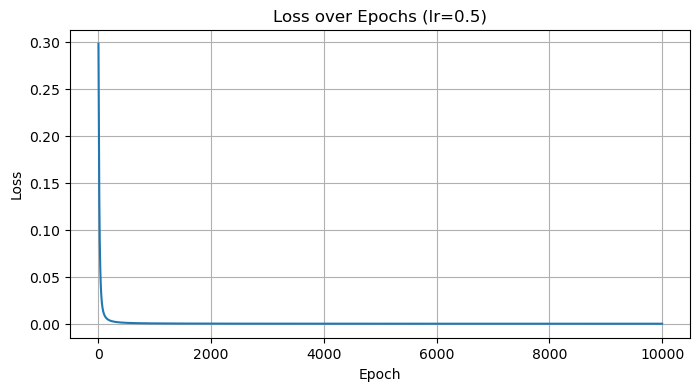

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title("Loss over Epochs (lr=0.5)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [11]:
print("=== Experiment: Learning Rate Comparison ===\n")

for lr_val in [0.5, 0.001]:
    print(f"--- lr = {lr_val} ---")
    losses_exp = train(X, y, epochs=5000, lr=lr_val)
    print(f"Final Loss: {losses_exp[-1]:.8f}\n")

=== Experiment: Learning Rate Comparison ===

--- lr = 0.5 ---
Epoch     0 | Loss: 0.29837111 | y1: 0.7514 | y2: 0.7729
Epoch  1000 | Loss: 0.00034608 | y1: 0.0287 | y2: 0.9715
Epoch  2000 | Loss: 0.00011935 | y1: 0.0210 | y2: 0.9791
Epoch  3000 | Loss: 0.00006015 | y1: 0.0178 | y2: 0.9823
Epoch  4000 | Loss: 0.00003543 | y1: 0.0160 | y2: 0.9841
Final Loss: 0.00002275

--- lr = 0.001 ---
Epoch     0 | Loss: 0.29837111 | y1: 0.7514 | y2: 0.7729
Epoch  1000 | Loss: 0.27261954 | y1: 0.7114 | y2: 0.7591
Epoch  2000 | Loss: 0.24627182 | y1: 0.6679 | y2: 0.7456
Epoch  3000 | Loss: 0.22061780 | y1: 0.6226 | y2: 0.7333
Epoch  4000 | Loss: 0.19675173 | y1: 0.5777 | y2: 0.7231
Final Loss: 0.17534482



In [12]:
print("""
=== How Backpropagation Works (in my own words) ===

Backpropagation is how a neural network learns from its mistakes.

1. FORWARD PASS: Input flows through the network layer by layer.
   Each neuron computes a weighted sum + bias, then applies an activation
   function (like sigmoid). The final outputs are the network's predictions.

2. LOSS CALCULATION: We compare predictions to actual targets using a
   loss function (e.g., squared error). A higher loss = worse predictions.

3. BACKWARD PASS: We compute how much each weight contributed to the error.
   Starting from the output, we use the chain rule to propagate error
   gradients backward — output layer first, then hidden layers.

4. WEIGHT UPDATE: Each weight is nudged in the direction that reduces the loss,
   scaled by the learning rate. Repeat for many epochs until loss converges.

Key insight: The chain rule lets us decompose complex gradients into simple
products of local derivatives — that's what makes backprop efficient.
""")


=== How Backpropagation Works (in my own words) ===

Backpropagation is how a neural network learns from its mistakes.

1. FORWARD PASS: Input flows through the network layer by layer.
   Each neuron computes a weighted sum + bias, then applies an activation
   function (like sigmoid). The final outputs are the network's predictions.

2. LOSS CALCULATION: We compare predictions to actual targets using a
   loss function (e.g., squared error). A higher loss = worse predictions.

3. BACKWARD PASS: We compute how much each weight contributed to the error.
   Starting from the output, we use the chain rule to propagate error
   gradients backward — output layer first, then hidden layers.

4. WEIGHT UPDATE: Each weight is nudged in the direction that reduces the loss,
   scaled by the learning rate. Repeat for many epochs until loss converges.

Key insight: The chain rule lets us decompose complex gradients into simple
products of local derivatives — that's what makes backprop efficient.



In [17]:
# Implement forward pass and backpropagation from scratch using Python.
import numpy as np

def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
    return x*(1-x)

x = np.array([1,0])
target = np.array([1,0])

w1,w2,w3,w4 = 0.2,-0.3,0.4,0.1
w5,w6,w7,w8 = -0.5,0.2,0.3,0.6
b1,b2 = 0.1,-0.2
b3,b4 = 0.2,-0.1
lr = 0.1

In [18]:
i1 = x[0]*w1 + x[1]*w3 + b1
i2 = x[0]*w2 + x[1]*w4 + b2
a1 = sigmoid(i1)
a2 = sigmoid(i2)

print("=== Hidden Layer ===")
print(f"i1 = {i1:.6f}")
print(f"i2 = {i2:.6f}")
print(f"a1 = {a1:.6f}")
print(f"a2 = {a2:.6f}")

=== Hidden Layer ===
i1 = 0.300000
i2 = -0.500000
a1 = 0.574443
a2 = 0.377541


In [19]:
i3 = a1*w5 + a2*w7 + b3
i4 = a1*w6 + a2*w8 + b4
y1 = sigmoid(i3)
y2 = sigmoid(i4)

print("=== Output Layer ===")
print(f"i3 = {i3:.6f}")
print(f"i4 = {i4:.6f}")
print(f"y1 = {y1:.6f}")
print(f"y2 = {y2:.6f}")

=== Output Layer ===
i3 = 0.026041
i4 = 0.241413
y1 = 0.506510
y2 = 0.560062


In [20]:
loss = 0.5*((target[0]-y1)**2 + (target[1]-y2)**2)
print(f"=== Loss ===")
print(f"Loss = {loss:.6f}")

=== Loss ===
Loss = 0.278601


In [21]:
err1 = -(target[0]-y1)*sigmoid_derivative(y1)
err2 = -(target[1]-y2)*sigmoid_derivative(y2)

print("=== Output Layer Errors ===")
print(f"err1 = {err1:.6f}")
print(f"err2 = {err2:.6f}")
print()
if err1 > 0:
    print(f"err1 is positive → y1 ({y1:.4f}) > target ({target[0]}) → overshot")
else:
    print(f"err1 is negative → y1 ({y1:.4f}) < target ({target[0]}) → undershot")
if err2 > 0:
    print(f"err2 is positive → y2 ({y2:.4f}) > target ({target[1]}) → overshot")
else:
    print(f"err2 is negative → y2 ({y2:.4f}) < target ({target[1]}) → undershot")

=== Output Layer Errors ===
err1 = -0.123352
err2 = 0.137995

err1 is negative → y1 (0.5065) < target (1) → undershot
err2 is positive → y2 (0.5601) > target (0) → overshot


In [22]:
dw5 = err1*a1
dw6 = err2*a1
dw7 = err1*a2
dw8 = err2*a2
db3 = err1
db4 = err2

print("=== Gradients for Output Weights ===")
print(f"dw5 = {dw5:.6f}")
print(f"dw6 = {dw6:.6f}")
print(f"dw7 = {dw7:.6f}")
print(f"dw8 = {dw8:.6f}")
print(f"db3 = {db3:.6f}")
print(f"db4 = {db4:.6f}")

=== Gradients for Output Weights ===
dw5 = -0.070858
dw6 = 0.079270
dw7 = -0.046570
dw8 = 0.052099
db3 = -0.123352
db4 = 0.137995


In [23]:
err_h1 = sigmoid_derivative(a1)*(err1*w5 + err2*w6)
err_h2 = sigmoid_derivative(a2)*(err1*w7 + err2*w8)

dw1 = err_h1*x[0]
dw2 = err_h2*x[0]
dw3 = err_h1*x[1]
dw4 = err_h2*x[1]
db1 = err_h1
db2 = err_h2

print("=== Hidden Layer Errors & Gradients ===")
print(f"err_h1 = {err_h1:.6f}")
print(f"err_h2 = {err_h2:.6f}")
print(f"dw1={dw1:.6f}, dw2={dw2:.6f}, dw3={dw3:.6f}, dw4={dw4:.6f}")
print(f"db1={db1:.6f}, db2={db2:.6f}")
print()
print("We sum over next layer errors because each hidden neuron connects to ALL output neurons.")
print("Total error responsibility = weighted sum of all downstream errors.")

=== Hidden Layer Errors & Gradients ===
err_h1 = 0.021824
err_h2 = 0.010761
dw1=0.021824, dw2=0.010761, dw3=0.000000, dw4=0.000000
db1=0.021824, db2=0.010761

We sum over next layer errors because each hidden neuron connects to ALL output neurons.
Total error responsibility = weighted sum of all downstream errors.


In [24]:
w1 -= lr*dw1
w2 -= lr*dw2
w3 -= lr*dw3
w4 -= lr*dw4
w5 -= lr*dw5
w6 -= lr*dw6
w7 -= lr*dw7
w8 -= lr*dw8
b1 -= lr*db1
b2 -= lr*db2
b3 -= lr*db3
b4 -= lr*db4

print("=== Updated Weights ===")
print(f"w1={w1:.6f}, w2={w2:.6f}, w3={w3:.6f}, w4={w4:.6f}")
print(f"w5={w5:.6f}, w6={w6:.6f}, w7={w7:.6f}, w8={w8:.6f}")
print(f"b1={b1:.6f}, b2={b2:.6f}, b3={b3:.6f}, b4={b4:.6f}")

=== Updated Weights ===
w1=0.197818, w2=-0.301076, w3=0.400000, w4=0.100000
w5=-0.492914, w6=0.192073, w7=0.304657, w8=0.594790
b1=0.097818, b2=-0.201076, b3=0.212335, b4=-0.113800


In [25]:
def train(x, target, epochs=10000, lr=0.1):
    w1,w2,w3,w4 = 0.2,-0.3,0.4,0.1
    w5,w6,w7,w8 = -0.5,0.2,0.3,0.6
    b1,b2 = 0.1,-0.2
    b3,b4 = 0.2,-0.1
    losses = []

    for epoch in range(epochs):
        i1 = x[0]*w1 + x[1]*w3 + b1
        i2 = x[0]*w2 + x[1]*w4 + b2
        a1 = sigmoid(i1)
        a2 = sigmoid(i2)

        i3 = a1*w5 + a2*w7 + b3
        i4 = a1*w6 + a2*w8 + b4
        y1 = sigmoid(i3)
        y2 = sigmoid(i4)

        loss = 0.5*((target[0]-y1)**2 + (target[1]-y2)**2)
        losses.append(loss)

        err1 = -(target[0]-y1)*sigmoid_derivative(y1)
        err2 = -(target[1]-y2)*sigmoid_derivative(y2)

        dw5 = err1*a1
        dw6 = err2*a1
        dw7 = err1*a2
        dw8 = err2*a2
        db3 = err1
        db4 = err2

        err_h1 = sigmoid_derivative(a1)*(err1*w5 + err2*w6)
        err_h2 = sigmoid_derivative(a2)*(err1*w7 + err2*w8)

        dw1 = err_h1*x[0]
        dw2 = err_h2*x[0]
        dw3 = err_h1*x[1]
        dw4 = err_h2*x[1]
        db1 = err_h1
        db2 = err_h2

        w1-=lr*dw1; w2-=lr*dw2; w3-=lr*dw3; w4-=lr*dw4
        w5-=lr*dw5; w6-=lr*dw6; w7-=lr*dw7; w8-=lr*dw8
        b1-=lr*db1; b2-=lr*db2; b3-=lr*db3; b4-=lr*db4

        if epoch % 1000 == 0:
            print(f"Epoch {epoch:5d} | Loss: {loss:.8f} | y1: {y1:.4f} | y2: {y2:.4f}")

    return losses

losses = train(x, target, epochs=10000, lr=0.1)
print("\nLoss is decreasing → network is learning!")

Epoch     0 | Loss: 0.27860087 | y1: 0.5065 | y2: 0.5601
Epoch  1000 | Loss: 0.00389022 | y1: 0.9383 | y2: 0.0630
Epoch  2000 | Loss: 0.00166846 | y1: 0.9596 | y2: 0.0413
Epoch  3000 | Loss: 0.00102769 | y1: 0.9683 | y2: 0.0324
Epoch  4000 | Loss: 0.00073212 | y1: 0.9732 | y2: 0.0274
Epoch  5000 | Loss: 0.00056425 | y1: 0.9765 | y2: 0.0240
Epoch  6000 | Loss: 0.00045683 | y1: 0.9789 | y2: 0.0216
Epoch  7000 | Loss: 0.00038254 | y1: 0.9807 | y2: 0.0198
Epoch  8000 | Loss: 0.00032829 | y1: 0.9821 | y2: 0.0183
Epoch  9000 | Loss: 0.00028703 | y1: 0.9833 | y2: 0.0172

Loss is decreasing → network is learning!


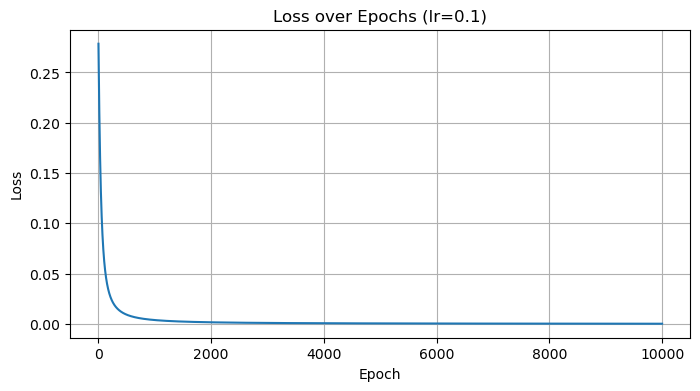

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(losses)
plt.title("Loss over Epochs (lr=0.1)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [27]:
print("=== Experiment: Learning Rate Comparison ===\n")
for lr_val in [0.5, 0.001]:
    print(f"--- lr = {lr_val} ---")
    losses_exp = train(x, target, epochs=5000, lr=lr_val)
    print(f"Final Loss: {losses_exp[-1]:.8f}\n")

=== Experiment: Learning Rate Comparison ===

--- lr = 0.5 ---
Epoch     0 | Loss: 0.27860087 | y1: 0.5065 | y2: 0.5601
Epoch  1000 | Loss: 0.00056414 | y1: 0.9765 | y2: 0.0240
Epoch  2000 | Loss: 0.00025478 | y1: 0.9842 | y2: 0.0162
Epoch  3000 | Loss: 0.00016137 | y1: 0.9875 | y2: 0.0129
Epoch  4000 | Loss: 0.00011711 | y1: 0.9893 | y2: 0.0110
Final Loss: 0.00009151

--- lr = 0.001 ---
Epoch     0 | Loss: 0.27860087 | y1: 0.5065 | y2: 0.5601
Epoch  1000 | Loss: 0.23159957 | y1: 0.5501 | y2: 0.5106
Epoch  2000 | Loss: 0.19337841 | y1: 0.5881 | y2: 0.4659
Epoch  3000 | Loss: 0.16274931 | y1: 0.6209 | y2: 0.4264
Epoch  4000 | Loss: 0.13831642 | y1: 0.6492 | y2: 0.3919
Final Loss: 0.11879945

